>### 1.What is Context
>### 2.What is MCP
>### 3.Problems with Tools and How MCP Solves Them
>### 4.Advantage of MCP
>### 5.MCP Architecture
>### 6.MCP Lifecycle

# What is Context?

**Context is everything the AI can see and use when generating a response.**

It can include:

- User prompt
- System instructions
- Conversation history
- Files and documents
- Retrieved information
- Tool results
- Other relevant application data

The LLM uses this information to understand the task and generate its response.

> **The model can only use information that is available within its context window.**

Therefore, providing the **right and relevant context** is important for generating accurate and useful responses.


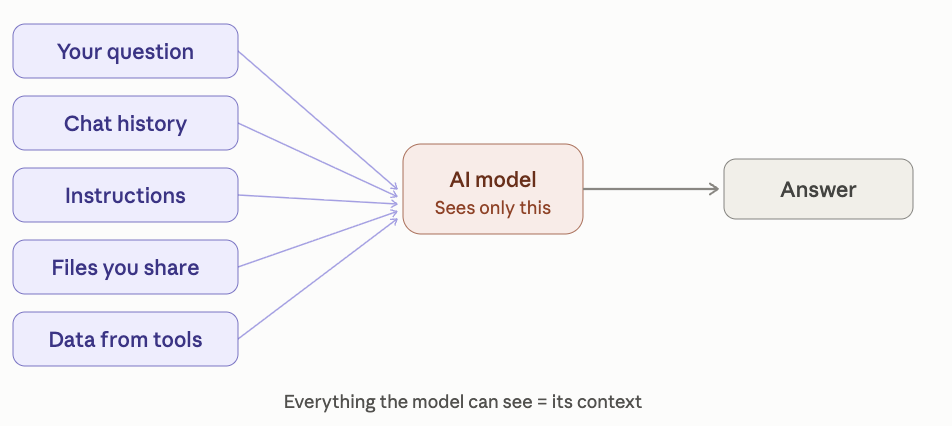

In [3]:
from IPython.display import Image, display
display(Image(filename="image/context.png", width=600))

# What is MCP(Model Context Protocol)

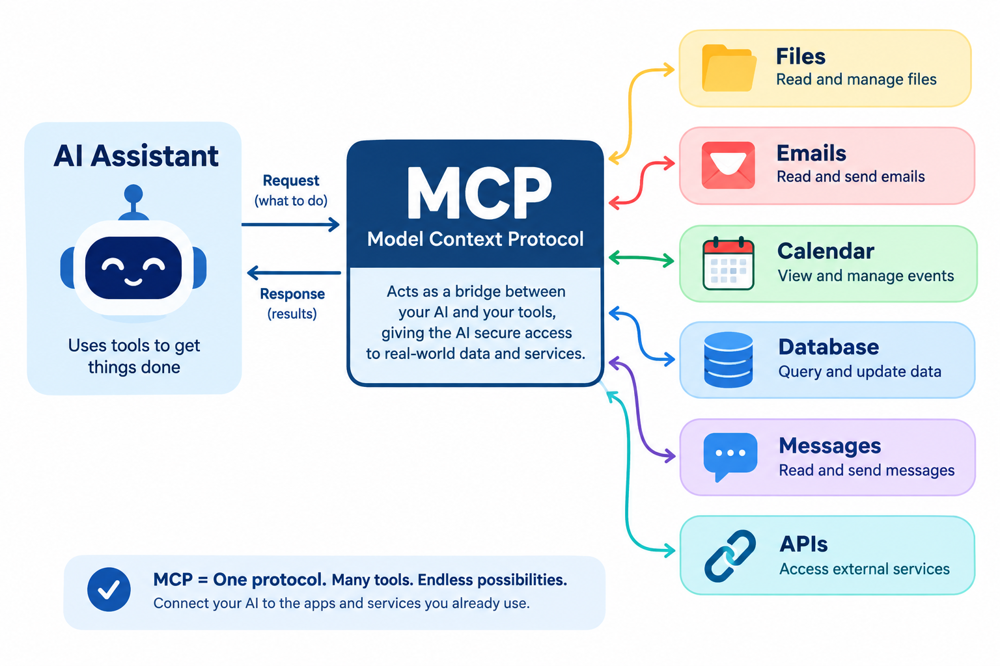

In [12]:
display(Image(filename="image/mcp.png", width=500))

**MCP (Model Context Protocol) is a common standard that lets AI connect with apps, tools, and data.**

In simple words:

>Context is the information the AI can use, while MCP is a standardized way for AI applications to connect to external sources of that information and capabilities.

## Simple Example

Think of a **USB-C charger**.

Before USB-C, different devices often needed different chargers and cables.

With USB-C, many devices can use the **same standard connection**.

MCP does something similar for AI:

- **Without MCP:** Every AI application may need a separate custom connection for Google Drive, Slack, GitHub, databases, etc.
- **With MCP:** AI applications and tools can communicate using a **common standard**.




## Why Does MCP Matter?

An AI cannot automatically access your:

- 📁 Files
- 📧 Emails
- 📅 Calendar
- 🗄️ Database
- 💬 Messages
- 🔗 APIs

MCP provides a **standard way for AI applications to interact with these external systems**.
## In One Line

> **MCP is a standard connector between AI applications and external tools, making integrations more reusable and easier to manage.**

#### Easy Way to Remember

MCP = Common Language between AI and Tools


# Problems with Tools and How MCP Solves Them

## The Core Problem with Tools

An LLM cannot directly access external systems such as files, databases, APIs, or applications. It needs **tools** or integrations to access them.

Before MCP, every AI application typically had to build its own custom integration with each external tool.

If there are **M applications** and **N tools**, this can lead to approximately:

**M × N integrations**

### Example

- 3 AI applications
- 4 external tools
- Traditional approach → **3 × 4 = 12 integrations**

With **MCP (Model Context Protocol)**:

- Each application implements MCP support once.
- Each tool/service provides an MCP server.
- Total integration points become approximately **M + N**.

For the same example:
**3 + 4 = 7 integration points**

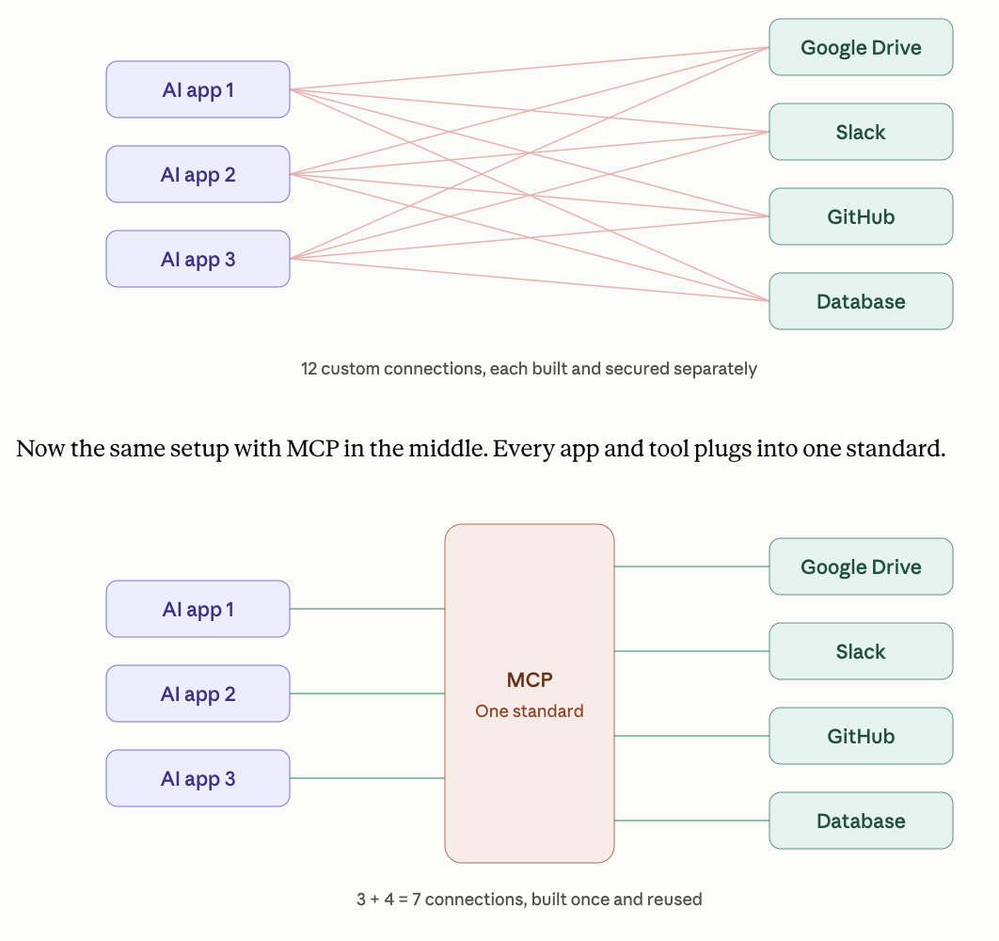

In [2]:
display(Image(filename="image/tool problem.png", width=700))

## Advantage of MCP
## 1. Maintenance Problem

### Before MCP

If a tool's API changes, every application that directly integrates with that API may need to be updated.

### With MCP

The **MCP server** can handle the tool-specific API changes. Applications continue communicating through the standard MCP interface.

---

## 2. Security Fragmentation

### Before MCP

Each custom integration may implement:

- Authentication
- Authorization
- Data-access rules
- Permission management

differently.

This makes security harder to manage consistently.

### With MCP

MCP provides a standardized communication model, making it easier to establish consistent authentication, authorization, and access-control practices.

> **Note:** MCP itself does not automatically guarantee security. The actual security depends on how the MCP client, server, authentication, and permissions are configured.

---

## 3. Cost and Time

### Before MCP

Teams repeatedly build and maintain similar integrations for different applications.

This results in:

- More development effort
- More maintenance
- Duplicate code
- Higher cost

### With MCP

An existing **MCP server** can be reused by multiple MCP-compatible applications.

This reduces duplicated integration work and speeds up development.

---

## Summary Table

| Problem | Before MCP | With MCP |
|---|---|---|
| **Integrations** | M × N custom integrations | Approximately M + N |
| **Maintenance** | Changes may require updates across many apps | Tool-specific changes can be handled in MCP server |
| **Security** | Different implementations across integrations | Standardized protocol + server-side controls |
| **Cost & Time** | Repeated integration work | Reusable MCP servers |


### MCP Architecture
#### 1. MCP Architecture Components
      1.1 Host
      1.2 Client
      1.3 Server
      1.4 Data layer (JSON-RPC 2.0)
      1.5 Transport Layer (STDIO/HTTP/HTTP+SSE)
#### 2. Benefits of MCP Architecture
        2.1 Decoupling
        2.2 Scalability
        2.3 Standardization
#### 3. MCP Primitives
        3.1 Tools
        3.2 Resources
        3.3 Prompts
#### 4. Data Layer
        4.1 JSON-RPC 2.0
             4.1.1 RPC (Remote Procedure Call)
             4.1.2 JSON-RPC
        4.2 JSON-RPC Request
        4.3 JSON-RPC Response
        4.4 JSON-RPC Error
        4.5 JSON-RPC Notification
        4.6 Why MCP Uses JSON-RPC Instead of REST?
            4.6.1 Lightweight Protocol
            4.6.2 Bidirectional Communication
            4.6.3 Transport-Agnostic
            4.6.4 Supports Batching
            4.6.5 Supports Notifications
#### 5. Transport Layer
        5.1 Local Servers — STDIO
        5.2 Remote Servers — HTTP
            5.2.1 HTTP + SSE

# 1. MCP Architecture Components and Communication

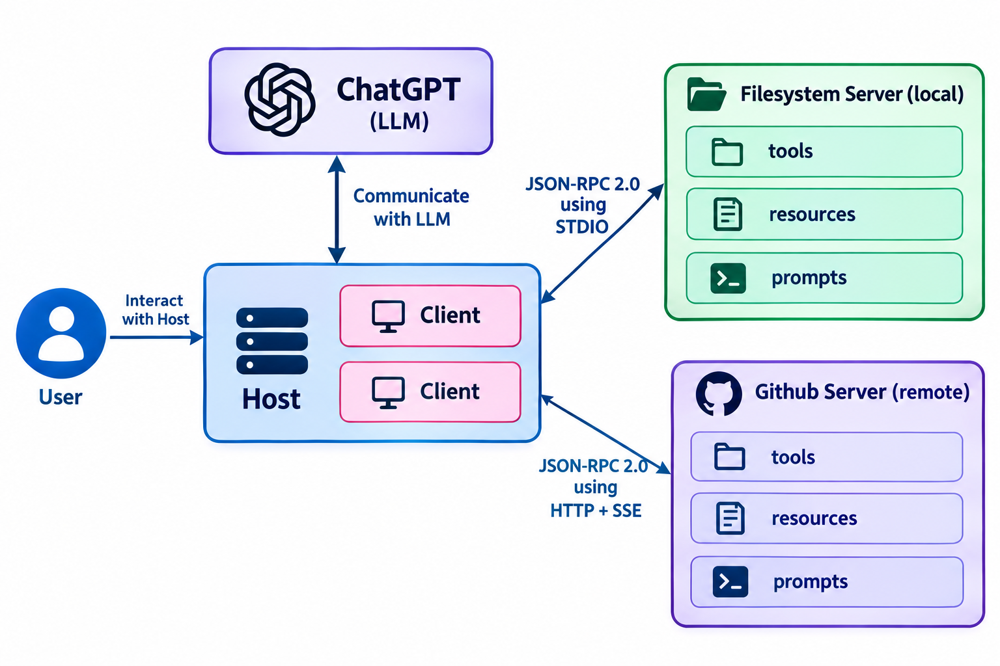

In [5]:
display(Image(filename="image/MCPA.png", width=500))

A **chatbot** takes messages from the user and sends them to an **LLM**. When the LLM needs to perform an external task—such as accessing a database, reading files, or calling an API—it may need to communicate with an external **MCP Server**.

The **Host Application** does not communicate directly with the MCP Server. Instead, it communicates through an **MCP Client**.

Typically, for each MCP Server, the Host maintains a corresponding MCP Client, creating a **one-to-one or or one-to-many** relationship  between the MCP Client and MCP Server.

---

## Local and Remote MCP Servers

MCP Servers can be either **local** or **remote**:

- **Local MCP Server** → Runs on the same machine as the Host Application.
- **Remote MCP Server** → Runs on another machine or server and communicates over a network.

Regardless of whether the server is local or remote, an MCP Server can expose three main primitives:

| Primitive | Purpose |
|---|---|
| **Tools** | Allow the LLM to perform actions, such as calling an API or querying a database |
| **Resources** | Provide data or context to the LLM |
| **Prompts** | Provide reusable prompt templates |

---

## MCP Communication

The communication between the **MCP Client** and **MCP Server** uses **JSON-RPC 2.0 messages**.

The transport mechanism can differ depending on whether the server is local or remote:

### Local MCP Server

Local MCP Servers commonly communicate using:

```text
STDIO
```

### Remote MCP Server

Remote MCP Servers commonly use network-based transports such as:

```text
Streamable HTTP
```

> **HTTP+SSE** was used in earlier MCP transport specifications.

---

## Simple MCP Architecture

```text
                 ┌─────────────────┐
                 │      User       │
                 └────────┬────────┘
                          │
                          ▼
                 ┌─────────────────┐
                 │      Host       │
                 │   Application   │
                 └────────┬────────┘
                          │
                          ▼
                 ┌─────────────────┐
                 │   MCP Client    │
                 └────────┬────────┘
                          │
                    JSON-RPC 2.0
                          │
                          ▼
                 ┌─────────────────┐
                 │   MCP Server    │
                 └───────┬─────────┘
                         │
             ┌───────────┼───────────┐
             ▼           ▼           ▼
          Tools      Resources     Prompts
```

### Key Takeaway

> **Host → MCP Client → MCP Server → Tools / Resources / Prompts**

The **Host** communicates with the **MCP Client**, the **MCP Client** communicates with the **MCP Server**, and the **MCP Server** provides **Tools, Resources, and Prompts**.

## How MCP Client Discovers and Uses Tools

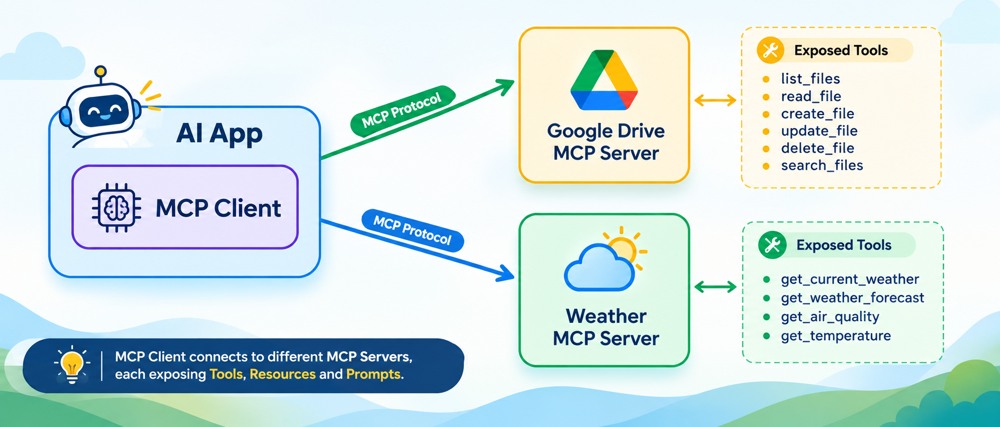

In [9]:
display(Image(filename="image/MCPFlow2.png", width=800))

Whenever the **AI App starts**, one of the first things that happens is that the **MCP Client connects to the available MCP Servers**. During this connection, the MCP Client asks each MCP Server what tools it provides. Each MCP Server returns its **list of available tools**, and the MCP Client collects and stores this information. The MCP Client then makes these available to the **AI App and the LLM**, so the LLM knows which tools are available and which MCP Server provides each tool. When the user asks a question, the question is sent to the **LLM**. The LLM first determines whether it can answer the question using its own knowledge. If it can, it generates the answer directly. If it cannot, it looks at the available **list of tools** provided by the MCP Servers and decides whether one of those tools can help answer the question.

For example, if the user asks, **“What is the current weather in Delhi?”**, the LLM may determine that it does not have real-time weather information. It then looks at the available tools and finds a tool called **`Get Current Weather`**, which is provided by the **Weather MCP Server**. The important point is that the **LLM decides which tool needs to be used**. Once the LLM decides to use the `Get Current Weather` tool, it generates a **tool request** and sends it to the **MCP Client**. The MCP Client then looks at the tool name and already knows which MCP Server provides that tool because it learned this information when the AI App initially connected to the MCP Servers. Therefore, the MCP Client routes the tool request to the **Weather MCP Server**.

Once the MCP Client connects the request to the appropriate MCP Server, the **MCP Server handles the actual execution of the tool**. In this example, the Weather MCP Server receives the request for the current weather in Delhi and internally communicates with the **Weather API** to retrieve the required information. The Weather MCP Server handles the API URL, parameters, authentication, and other implementation details required to call the external API. The AI App and LLM do not need to directly interact with the Weather API. In simple terms, **the LLM decides which tool to use, the MCP Client routes the request to the correct MCP Server, and the MCP Server performs the actual work using the required external service or API**.

# How MCP Handles a Weather Request

The user’s question is **“What is the weather in Delhi today?”** The question first goes to the **LLM**, and the LLM decides that it needs to use the **Get Current Weather** tool. The **MCP Client** then connects to the **Weather MCP Server** because the Get Current Weather tool is exposed by that server. One important thing to note here is that whenever the **MCP Client and MCP Server exchange messages**, the messages are exchanged in the **JSON-RPC 2.0 format**. The user’s original question is therefore converted into a JSON-RPC request containing the tool call and the required argument, which is the city **Delhi**. This JSON-RPC request is sent from the MCP Client to the Weather MCP Server. The Weather MCP Server then uses the **Weather API** to retrieve the actual weather information. Once the Weather API returns the result, the MCP Server converts that result into a **JSON-RPC 2.0 response**, for example, **temperature: 38°C** and **condition: Sunny**. This JSON-RPC response is then sent back to the MCP Client. The MCP Client passes the response to the **LLM**, and the LLM converts the structured information into a **human-readable answer** before displaying the final response to the user.

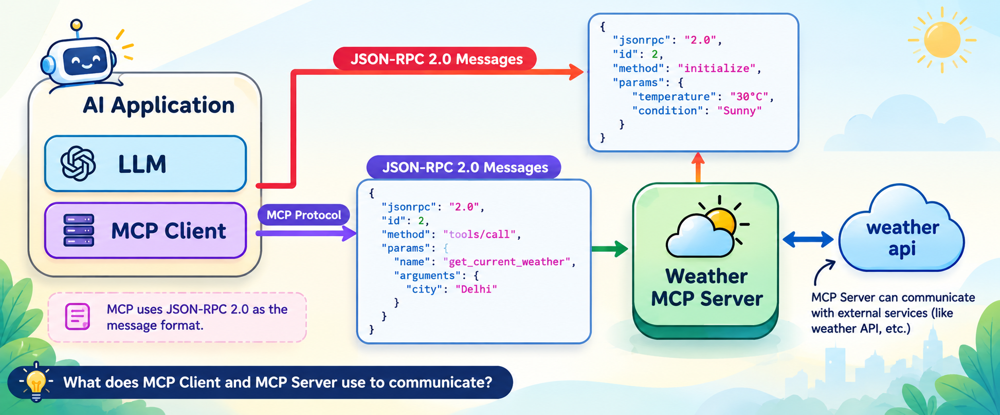

In [8]:
display(Image(filename="image/MCPFlow.png", width=800))

The user’s question is:

> **“What is the weather in Delhi today?”**

The question first goes to the **LLM**, and the LLM decides that it needs to use a tool. The **MCP Client** then connects to the appropriate **MCP Server**.

One important thing to note is that whenever the **MCP Client and MCP Server exchange messages**, those messages are sent in the **JSON-RPC 2.0 format**.

The user’s original question is converted into a **JSON-RPC request**, which contains the tool call and its required arguments:

```json
{
  "jsonrpc": "2.0",
  "id": 2,
  "method": "tools/call",
  "params": {
    "name": "get_current_weather",
    "arguments": {
      "city": "Delhi"
    }
  }
}
```

This request is sent to the **Weather MCP Server** because the `get_current_weather` tool belongs to that server.

The **Weather MCP Server** then uses the **Weather API** to retrieve the actual weather information. Once the Weather API returns the result, the MCP Server sends the response back to the MCP Client, again using the **JSON-RPC 2.0 format**.

For example:

```json
{
  "jsonrpc": "2.0",
  "id": 2,
  "result": {
    "temperature": "38°C",
    "condition": "Sunny"
  }
}
```

The **MCP Client** then passes this response back to the **LLM**. The LLM converts the structured result into a **human-readable answer**, which is finally shown to the user.

### Complete Flow

```text
User
  ↓
"What is the weather in Delhi today?"
  ↓
LLM
  ↓
Decides to use Get Current Weather tool
  ↓
MCP Client
  ↓
JSON-RPC 2.0 Request
  ↓
Weather MCP Server
  ↓
Weather API
  ↓
Weather Result
  ↓
Weather MCP Server
  ↓
JSON-RPC 2.0 Response
  ↓
MCP Client
  ↓
LLM
  ↓
Human-readable response
  ↓
User
```

### Key Point

> **MCP Client ↔ MCP Server communication uses JSON-RPC 2.0 messages.**

The **MCP Server** can then communicate with external services such as a weather API, database, or other APIs to perform the actual task.

# 2. Benefits of MCP Architecture

### 2.1 Decoupling 

Each MCP Server has its own **MCP Client connection**, so one communication channel does not depend on the others. For example, if the **GitHub MCP Server** has a connection problem, the **Slack** and **Google Drive** MCP Servers can continue working independently. This provides better isolation and reliability. It also allows tasks involving multiple MCP Servers to be executed **in parallel** when appropriate—for example, one request may need information from both Slack and GitHub—helping reduce overall execution time.

### 2.2 Scalability

MCP makes it easy to connect **multiple MCP Servers to a single Host Application**. As the application grows, you can add more servers without redesigning the existing architecture. Typically, each MCP Server has a corresponding **MCP Client**, so adding a new capability can be as simple as adding a new MCP Server and its client connection. For example, the same AI application can connect to **GitHub, Slack, Google Drive, Weather, and Database MCP Servers**, with each server providing its own set of tools and capabilities.

### 2.3 Standardization

MCP provides a **common way for AI applications and MCP Servers to communicate**. Instead of creating a different connection for every tool or service, everyone follows the same MCP rules. MCP uses **JSON-RPC 2.0** to exchange messages between the MCP Client and MCP Server. Because of this common standard, different MCP Servers can easily work with different AI applications without requiring a completely new integration each time.

# 3. MCP Primitives — What an MCP Server Provides

**Primitives** are simply the different things an **MCP Server can provide to an AI application**.

There are **3 main primitives**:

> **Tools → Do something**  
> **Resources → Read something**  
> **Prompts → Guide the AI**

---

## 3.1 Tools — **Do Something**

**Tools are actions that the AI can ask the MCP Server to perform.**

Think of a tool like a **function**.

### Examples

For example, when the user asks:

> **“What is the weather in Delhi today?”**

The LLM selects the `get_current_weather` tool from the **Weather MCP Server**.

```text
LLM → MCP Client → Weather MCP Server → Weather API
```

The server gets the result, such as **38°C, Sunny**, and sends it back.

> **Tool = Perform an action or get dynamic information.**
---

## 3.2 Resources — **Read Something**

**Resources are data or documents that the AI can read.**

Think of a resource like a **file or document** that the server makes available to the AI.

### Examples

**GitHub MCP Server:**
- Repository README

**Database MCP Server:**
- Database schema

For example, if the AI needs to understand the structure of a database, it can read the database schema provided as a resource.

### Remember

> **Resource = Read data**

Resources are generally used for **reference information or content**, rather than performing an action.

---
### 3.3 Prompts — Weather Example

**Prompts are predefined instructions that guide the AI on how to perform a task.**

For example, a Weather MCP Server may provide a prompt:

> **“Provide the weather information in a simple format with temperature, condition, and location.”**

The LLM follows this instruction to generate a clear response.

> **Prompt = Guide the AI on how to respond.**
---

# Tools vs Resources vs Prompts

| Primitive | Simple Meaning | Example |
|---|---|---|
| **Tools** | Do something | Get current weather |
| **Resources** | Read something | Weather information/document|
| **Prompts** | Guide the AI | Format weather response with temperature and condition|

### Easy Way to Remember

> 🔧 **Tools → Do**  
> 📄 **Resources → Read**  
> 📝 **Prompts → Guide**

**One-line summary:**  
**Tools perform actions, Resources provide information, and Prompts guide the AI on how to perform a task.**

# 4. Data Layer

**Definition:**  
The **Data Layer** is the common language and grammar of the **MCP ecosystem**. It defines how MCP clients and servers communicate, including the message structure, syntax, and communication rules.

**Key Fact:**  
**JSON-RPC 2.0** is the foundation of the MCP Data Layer. It provides the standard rules for creating requests, responses, and errors.

### 4.1 What is JSON-RPC 2.0?

**JSON-RPC 2.0= JSON + RPC (Remote Procedure Call) + The current version is 2.0.**

**RPC (Remote Procedure Call)** allows one program to execute a function on another computer as if it were a local function.

For example:

```text
Local call:
add(2, 3)

RPC call:
"Run add with parameters 2 and 3"
```

The network communication and data transfer happen behind the scenes.

### Why JSON-RPC?

JSON-RPC provides a **simple, standardized JSON format** for communication between systems.

```text
Client
  │
  │ JSON-RPC Request
  ▼
Server
  │
  │ JSON-RPC Response
  ▼
Client
```

**In simple terms:**  
> **JSON-RPC 2.0 defines the grammar and structure that MCP uses to communicate between clients and servers.**

### Main MCP Messages

| MCP Method | Simple Meaning |
|---|---|
| `tools/list` | Show available tools |
| `tools/call` | Run a tool |
| `resources/list` | Show available resources |
| `resources/read` | Read a resource |

### Example: Call Weather Tool

```json
{
  "jsonrpc": "2.0",
  "method": "tools/call",
  "params": {
    "name": "get_weather",
    "arguments": {
      "city": "Delhi"
    }
  },
  "id": 1
}
```

**In short:**

> **MCP defines what to do, and JSON-RPC defines how the Client and Server communicate.**

## 4.2 JSON-RPC Request

**Client → Server:** Ask for weather.

```json
{
  "jsonrpc": "2.0",
  "method": "get_weather",
  "params": {
    "city": "Delhi"
  },
  "id": 1
}
```
| Field | Meaning |
|---|---|
| `jsonrpc` | JSON-RPC protocol version |
| `method` | Method/function to execute |
| `params` | Arguments passed to the method |
| `id` | Unique identifier used to match the response |
---

## 4.3 JSON-RPC Response

**Server → Client:** Return weather information.The important point is that the **id remains the same**.

```json
{
  "jsonrpc": "2.0",
  "result": {
    "temperature": "38°C",
    "condition": "Sunny"
  },
  "id": 1
}
```

---

## 4.4 JSON-RPC Error

**Server → Client:** Something went wrong.for example, the city doesn't exist:

```json
{
  "jsonrpc": "2.0",
  "error": {
    "code": -32602,
    "message": "City is required"
  },
  "id": 1
}
```
JSON-RPC defines standard error codes such as:
- -32600 → Invalid Request
- -32601 → Method Not Found
- -32602 → Invalid Parameters
- -32603 → Internal Error
---

## 4.5 JSON-RPC Notification

**Server → Client:** Send information without expecting a response.There is **no id**.

```json
{
  "jsonrpc": "2.0",
  "method": "weather/updated",
  "params": {
    "city": "Delhi"
  }
}
```

### ⭐ Easy to Remember

```text
Request      → Get Delhi weather
Response     → 38°C, Sunny
Error        → City is missing
Notification → Weather updated
```

## 4.6 Why MCP Uses JSON-RPC Instead of REST?

| **Reason** | **REST** | **JSON-RPC** |
|---|---|---|
| **4.6.1 Lightweight Protocol** | Uses HTTP headers and metadata. | Simple JSON messages; easy to send and debug. |
| **4.6.2 Bidirectional Communication** | Mainly follows **Client → Request → Server → Response**. | Supports communication in **both directions**. |
| **4.6.3 Transport-Agnostic** | Mainly associated with HTTP. | Can work with **HTTP, STDIO, WebSockets**, or other transports. |
| **4.6.4 Supports Batching** | Usually sends requests separately. | Can send **multiple requests together**. |
| **4.6.5 Supports Notifications** | Typically follows request → response. | Can send a message **without expecting a response**. |

### ⭐ Easy to Remember

> **JSON-RPC = Lightweight + Bidirectional + Flexible + Batching + Notifications**

## 5. Transport Layer

**Definition:**  
The **Transport Layer** defines **how JSON-RPC messages travel** between the MCP Client and MCP Server.

> **Data Layer = How messages are written** → JSON-RPC  
> **Transport Layer = How messages travel** → STDIO / HTTP

### 5.1 Types of MCP Servers

| | **Local Server** | **Remote Server** |
|---|---|---|
| Runs | Same computer | Different computer |
| Communication | **STDIO** | **HTTP** |
| Example | Filesystem server | GitHub server |

---

## 5.2 Local Server — STDIO

**STDIO = Standard Input / Output**

The host starts the MCP Server as a **subprocess**.

```text
Host / MCP Client
      │
      │ JSON-RPC
      │ stdin
      ▼
MCP Server
      │
      │ JSON-RPC
      │ stdout
      ▼
Host / MCP Client
```

- **stdin** → Server receives messages
- **stdout** → Server sends messages
- No network is required.

### Benefits

| Benefit | Why? |
|---|---|
| **Fast** | Same machine |
| **Secure** | No network port needed |
| **Simple** | Supported by most programming languages |

---

## 5.3 Remote Server — HTTP

For a remote MCP Server, communication happens over a network.

```text
MCP Client
    │
    │ HTTP
    ▼
Remote MCP Server
```

The JSON-RPC message is sent through the HTTP connection.

**Example:** A GitHub MCP Server running remotely.

---

### 5.3.1 HTTP + SSE

**SSE = Server-Sent Events**

SSE allows the server to **continuously send updates** to the client over an open HTTP connection.

```text
MCP Client
    │
    │ HTTP Request
    ▼
MCP Server
    │
    │ SSE
    ├────────► Update 1
    ├────────► Update 2
    └────────► Update 3
```

Useful for:

- Long-running tasks
- Progress updates
- Streaming results

> **Note:** HTTP+SSE was used by earlier MCP transport designs. Current MCP uses **Streamable HTTP** as the standard remote transport.

---

## 5.4 Why Separate Data and Transport Layers?

The **JSON-RPC message stays the same**, regardless of how it travels.

```text
              JSON-RPC
                 │
       ┌─────────┴─────────┐
       ▼                   ▼
     STDIO                HTTP
   (Local)              (Remote)
```

### ⭐ Easy to Remember

> **Data Layer = What is the message?**  
> **Transport Layer = How does the message travel?**

## Final Architecture

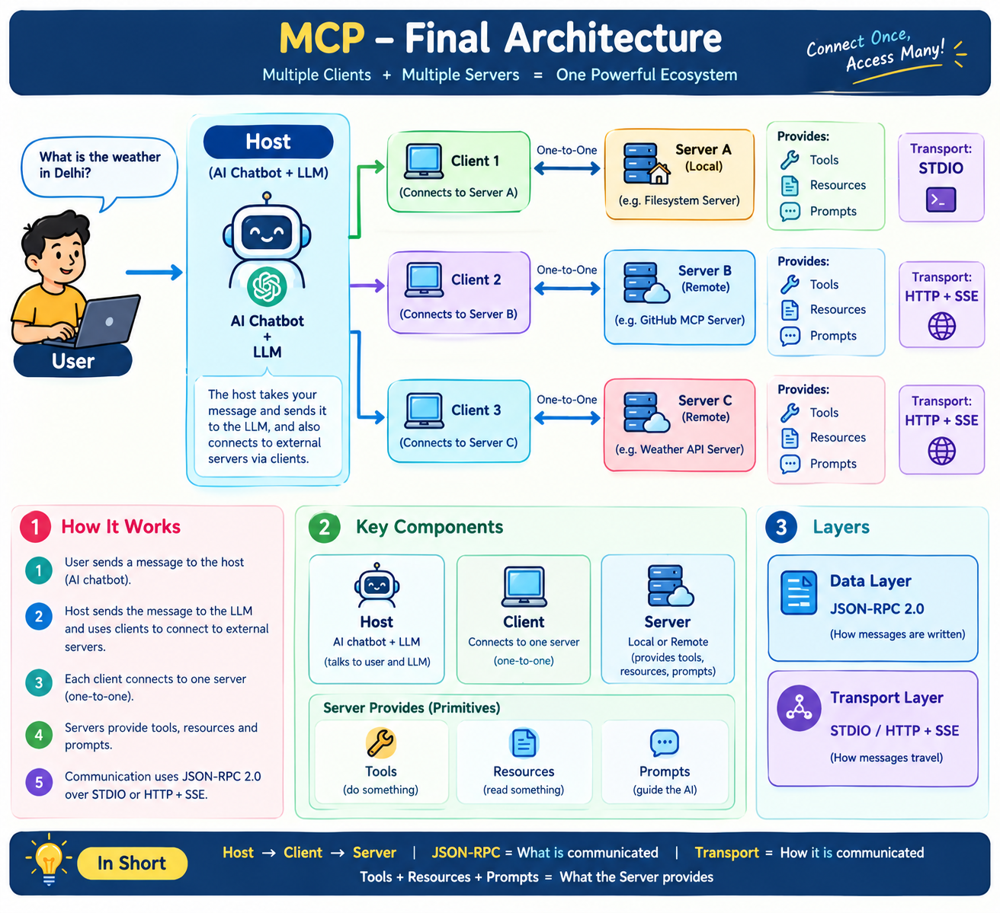

In [4]:
display(Image(filename="image/MCP4.png", width=800))

In MCP, the **Host** is the AI application or chatbot that communicates with the LLM and handles the user’s request. The Host uses an **MCP Client** to connect to an MCP Server. Each client has a **one-to-one connection with a server**. The server can be **local**, running on the same computer and communicating through **STDIO**, or **remote**, running on another computer and communicating through **HTTP**. MCP Servers provide **Tools, Resources, and Prompts**. The messages exchanged between the client and server are written using **JSON-RPC 2.0**, which is the **Data Layer**, while STDIO or HTTP is the **Transport Layer** that carries those messages.

> **In simple words:**  
> **Host → Client → Server**  
> **JSON-RPC = how messages are written**  
> **Transport = how messages travel**  
> **Tools, Resources, Prompts = what the server provides**

# 6.MCP Lifecycle

## Stages of the MCP Lifecycle

The Model Context Protocol (MCP) connection between a **client** and a **server** goes through three stages:

1. **Initialization**: negotiate protocol version and capabilities
2. **Operation**: normal message exchange (tools, resources, prompts)
3. **Shut down**: close the connection cleanly

> Version strings below (e.g. `2025-06-18`) are examples. Use the protocol version your SDK targets.

---

## Overview figure

```mermaid
flowchart TD
    A[MCP Lifecycle] --> B[Initialization]
    A --> C[Operation]
    A --> D[Shut down]
```

## Sequence figure

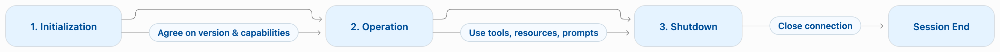

In [9]:
display(Image(filename="image/MCPFlow3.png", width=2000))


```mermaid
sequenceDiagram
    participant C as Client
    participant S as Server

    rect rgb(240, 240, 235)
    Note over C,S: Stage 1 - Initialization
    C->>S: initialize (version, capabilities)
    S-->>C: result (version, capabilities)
    C->>S: notifications/initialized
    end

    rect rgb(235, 245, 240)
    Note over C,S: Stage 2 - Operation
    C->>S: tools/list
    S-->>C: result (tools)
    C->>S: tools/call
    S-->>C: result (content)
    end

    rect rgb(245, 238, 235)
    Note over C,S: Stage 3 - Shut down
    C->>S: Close connection (no JSON-RPC message)
    Note over S: Server exits, resources released
    end
```

Solid arrows are requests or notifications. Dashed arrows are responses.

---

## Stage 1: Initialization

This must be the first interaction. Client and server agree on a protocol version and exchange **capabilities** (what each side supports). No other requests, except pings, should be sent until it completes.

### Step 1: Client sends `initialize`

```json
{
  "jsonrpc": "2.0",
  "id": 1,
  "method": "initialize",
  "params": {
    "protocolVersion": "2025-06-18",
    "capabilities": {
      "roots": { "listChanged": true },
      "sampling": {}
    },
    "clientInfo": {
      "name": "my-client",
      "version": "1.0.0"
    }
  }
}
```

### Step 2: Server responds

If the server supports the requested version it echoes it back. Otherwise it replies with another version it supports, and the client either accepts it or disconnects.

```json
{
  "jsonrpc": "2.0",
  "id": 1,
  "result": {
    "protocolVersion": "2025-06-18",
    "capabilities": {
      "tools": { "listChanged": true },
      "resources": { "subscribe": true, "listChanged": true },
      "prompts": { "listChanged": true },
      "logging": {}
    },
    "serverInfo": {
      "name": "my-server",
      "version": "1.0.0"
    }
  }
}
```

### Step 3: Client confirms with `initialized`

This is a **notification**: it has no `id` and expects no reply.

```json
{
  "jsonrpc": "2.0",
  "method": "notifications/initialized"
}
```

---

## Stage 2: Operation

Client and server now exchange messages normally, but only using the capabilities negotiated in Stage 1. If the server did not declare `tools`, the client must not call `tools/list`.

### Discover tools

Request:

```json
{ "jsonrpc": "2.0", "id": 2, "method": "tools/list" }
```

Response:

```json
{
  "jsonrpc": "2.0",
  "id": 2,
  "result": {
    "tools": [
      {
        "name": "get_weather",
        "description": "Get current weather for a city",
        "inputSchema": {
          "type": "object",
          "properties": { "city": { "type": "string" } },
          "required": ["city"]
        }
      }
    ]
  }
}
```

### Call a tool

Request:

```json
{
  "jsonrpc": "2.0",
  "id": 3,
  "method": "tools/call",
  "params": {
    "name": "get_weather",
    "arguments": { "city": "Bengaluru" }
  }
}
```

Response:

```json
{
  "jsonrpc": "2.0",
  "id": 3,
  "result": {
    "content": [
      { "type": "text", "text": "28°C, partly cloudy" }
    ],
    "isError": false
  }
}
```

### Other operation-phase messages

- **Ping**: either side can send `ping` to check the connection is alive; the receiver replies with an empty result.
- **Notifications**: servers can send e.g. `notifications/tools/list_changed`; clients can send `notifications/cancelled` to cancel an in-flight request.
- **Errors**: a failed request returns a JSON-RPC `error` instead of a `result`:

```json
{
  "jsonrpc": "2.0",
  "id": 3,
  "error": {
    "code": -32602,
    "message": "Unknown tool: get_weathr"
  }
}
```

Version or capability mismatches during initialization are reported the same way, with an `error` object and codes like `-32602` or `-32603`.

---

## Stage 3: Shut down

MCP defines **no shutdown message**. The connection is closed through the transport, so there is no JSON-RPC here.

| Transport | How shutdown works |
|---|---|
| **stdio** | Client closes the server's input stream and waits for it to exit. If it doesn't exit in time, the client sends `SIGTERM`, then `SIGKILL` if that also fails. |
| **Streamable HTTP** | Close the HTTP connection(s). The client may also send an HTTP `DELETE` with the session ID to end the session explicitly. |

**Tip:** set a timeout for every request and send `notifications/cancelled` when it expires, so a hung server can't stall the client forever.

---

## Quick summary

| Stage | Key messages | Purpose |
|---|---|---|
| Initialization | `initialize` → result → `notifications/initialized` | Agree on version and capabilities |
| Operation | `tools/list`, `tools/call`, `ping`, notifications | Do the actual work within negotiated capabilities |
| Shut down | Transport close (stdin close / HTTP close) | Release resources cleanly |

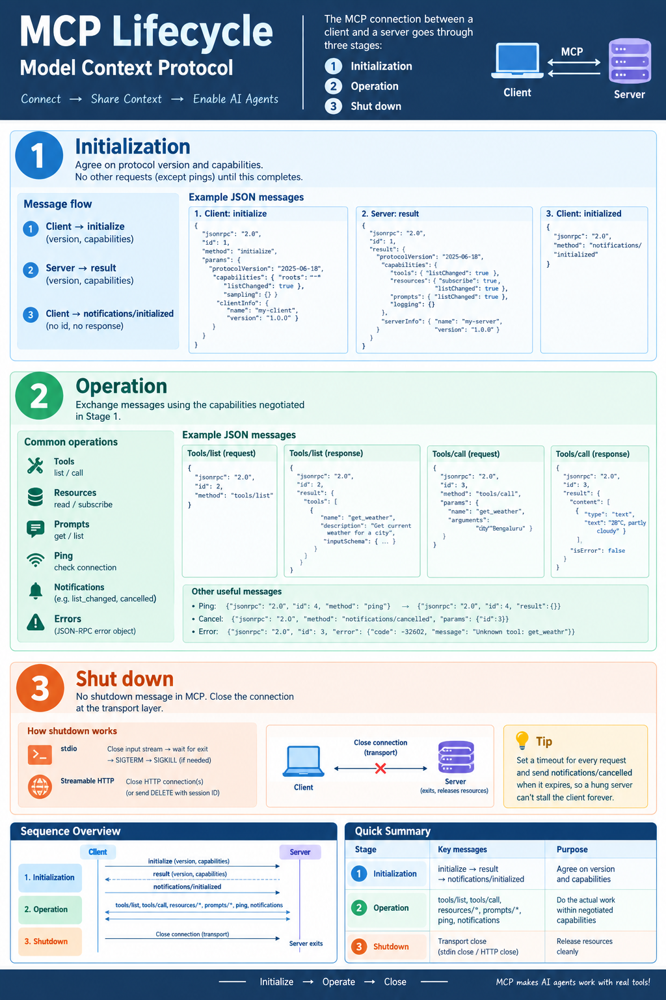

In [10]:
display(Image(filename="image/MCPFlow5.png", width=2000))

#### Likely interview questions

1. Why does MCP need a client between the host and the server?
2. What is the difference between a tool and a resource?
3. What is the purpose of the prompt primitive?
4. What is JSON-RPC, and why did MCP choose it over REST?
5. What is the difference between a request and a notification?
6. Explain how STDIO transport works for a local server.
7. Why does a remote server use HTTP + SSE? What does SSE add?
8. What is the benefit of separating the data layer from the transport layer?

